# Linear Model Selection and Regularization in Python - ISLP Chapter 6
**Annalise Banda | STA 6543**

# Q2
For parts (a) through (c), indicate which of i. through iv. is correct. Justify your answer.

(a) The lasso, relative to least squares, is:

    i. More flexible and hence will give improved prediction accuracy when its increase in bias is less than its decrease in variance.

    ii. More flexible and hence will give improved prediction accuracy when its increase in variance is less than its decrease in bias.

    iii. Less flexible and hence will give improved prediction accuracy when its increase in bias is less than its decrease in variance.

    iv. Less flexible and hence will give improved prediction accuracy when its increase in variance is less than its decrease in bias.

(b) Repeat (a) for ridge regression relative to least squares.

(c) Repeat (a) for non-linear methods relative to least squares.

### (a) Lasso vs. least squares

**Answer: iii.** The lasso shrinks coefficients toward zero and can set some of them exactly to zero, which restricts the model relative to ordinary least squares. It is **less flexible**. This added constraint raises bias (the fitted model is no longer the unconstrained minimizer of training RSS) but lowers variance (the fit is less sensitive to the particular training sample). The lasso improves prediction accuracy over least squares whenever that variance reduction outweighs the bias it introduces, which tends to happen when many predictors are irrelevant or weakly related to the response, or when $p$ is large relative to $n$.

### (b) Ridge regression vs. least squares

**Answer: iii.** Ridge regression is the same story as the lasso: the $\ell_2$ penalty shrinks all coefficients toward zero, making the model **less flexible** than least squares. This trades a small increase in bias for a often much larger decrease in variance, so ridge tends to win over least squares in exactly the same setting many correlated or noisy predictors, or $n$ not much bigger than $p$ whenever the variance reduction it buys exceeds the bias it costs.

### (c) Non-linear methods vs. least squares

**Answer: ii.** Non-linear methods (e.g., polynomial regression, splines, or other flexible non-parametric approaches) can capture curvature that a linear model cannot, making them **more flexible** than least squares. Flexibility lowers bias (the model can get closer to the true, possibly non-linear signal) but raises variance (more parameters means more sensitivity to the training data). These methods improve prediction accuracy over least squares only when that bias reduction is large enough to outweigh the added variance i.e., when the true relationship is genuinely non-linear and there is enough data to estimate the extra flexibility reliably.

# Q9
In this exercise, we will predict the number of applications received using the other variables in the College data set.

(a) Split the data set into a training set and a test set.

(b) Fit a linear model using least squares on the training set, and report the test error obtained.

(c) Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

(d) Fit a lasso model on the training set, with λ chosen by crossvalidation. Report the test error obtained, along with the number of non-zero coefficient estimates.

(e) Fit a PCR model on the training set, with M chosen by crossvalidation. Report the test error obtained, along with the value of M selected by cross-validation.

(f) Fit a PLS model on the training set, with M chosen by crossvalidation. Report the test error obtained, along with the value of M selected by cross-validation.

(g) Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much difference among the test errors resulting from these five approaches?

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import os
os.makedirs('figs', exist_ok=True)

college = pd.read_csv('College.csv')
first_col = college.columns[0]
college = college.rename(columns={first_col: 'Name'})
college['Private'] = (college['Private'] == 'Yes').astype(int)
college = college.set_index('Name')

X = college.drop(columns=['Apps'])
y = college['Apps']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print(f"Training set: {X_train.shape[0]} observations, {X_train.shape[1]} predictors")
print(f"Test set: {X_test.shape[0]} observations")


Training set: 543 observations, 17 predictors
Test set: 234 observations


### (a) Train/test split

The College data (777 schools, 17 predictors) is split 70/30 into a training set of 543 schools and a test set of 234 schools, using a fixed random seed so the same split is reused for every method below. Keeping the split identical across models is what makes the test-error comparisons in part (g) meaningful.

In [6]:

lr = LinearRegression().fit(X_train, y_train)
pred_ols = lr.predict(X_test)
mse_ols = mean_squared_error(y_test, pred_ols)
print(f"OLS test MSE: {mse_ols:,.2f}")
print(f"OLS test RMSE: {np.sqrt(mse_ols):,.1f} applications")


OLS test MSE: 642,753.90
OLS test RMSE: 801.7 applications


### (b) Least squares

Ordinary least squares gives a test MSE of **642,753.90** (RMSE $\approx$ 802 applications). Given that `Apps` ranges from under 100 to over 20,000 with a right-skewed distribution, an average miss of roughly 800 applications is reasonable though a far from perfect baseline that the regularized and dimension-reduction methods below will be compared against.

Ridge best lambda (CV): 11.768
Ridge test MSE: 684,445.91


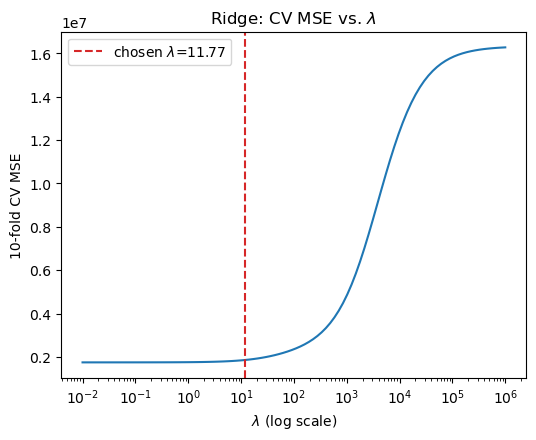

In [7]:

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

alphas = np.logspace(-2, 6, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=10).fit(X_train_s, y_train)
pred_ridge = ridge_cv.predict(X_test_s)
mse_ridge = mean_squared_error(y_test, pred_ridge)
print(f"Ridge best lambda (CV): {ridge_cv.alpha_:.3f}")
print(f"Ridge test MSE: {mse_ridge:,.2f}")

ridge_mse_path = [-np.mean([mean_squared_error(y_train.values[val], 
                    RidgeCV(alphas=[a], cv=None).fit(X_train_s[tr], y_train.values[tr]).predict(X_train_s[val]))
                    for tr, val in KFold(10, shuffle=True, random_state=1).split(X_train_s)]) for a in alphas]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(alphas, [-m for m in ridge_mse_path], color='tab:blue')
ax.axvline(ridge_cv.alpha_, color='tab:red', linestyle='--', label=f'chosen $\\lambda$={ridge_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('10-fold CV MSE')
ax.set_title('Ridge: CV MSE vs. $\\lambda$')
ax.legend()
plt.savefig('figs/q9c_ridge_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (c) Ridge regression

Cross-validation selects $\lambda \approx 11.77$, giving a test MSE of **684,445.91** slightly worse than plain least squares. Because ridge only shrinks coefficients and never removes a predictor entirely, it can't take advantage of any truly irrelevant variables the way lasso or a sparse method could; with only 17 predictors and 543 training observations here, least squares isn't overfitting badly to begin with, so ridge's variance reduction doesn't buy much and the added bias from shrinkage ends up costing slightly more than it saves.

Lasso best lambda (CV): 11.768
Lasso test MSE: 658,346.81
Non-zero coefficients: 14 out of 17
Predictors dropped: ['F.Undergrad', 'Books', 'Personal']


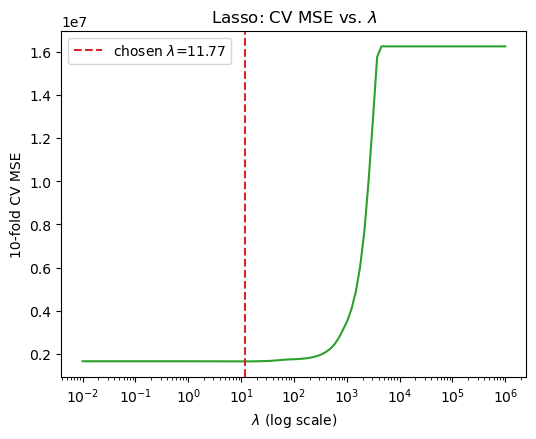

In [8]:

lasso_cv = LassoCV(alphas=alphas, cv=10, max_iter=100000, random_state=1).fit(X_train_s, y_train)
pred_lasso = lasso_cv.predict(X_test_s)
mse_lasso = mean_squared_error(y_test, pred_lasso)
n_nonzero = np.sum(lasso_cv.coef_ != 0)
print(f"Lasso best lambda (CV): {lasso_cv.alpha_:.3f}")
print(f"Lasso test MSE: {mse_lasso:,.2f}")
print(f"Non-zero coefficients: {n_nonzero} out of {X_train.shape[1]}")
dropped = list(X_train.columns[lasso_cv.coef_ == 0])
print(f"Predictors dropped: {dropped}")

fig, ax = plt.subplots(figsize=(6, 4.5))
mse_path_mean = lasso_cv.mse_path_.mean(axis=1)
ax.plot(lasso_cv.alphas_, mse_path_mean, color='tab:green')
ax.axvline(lasso_cv.alpha_, color='tab:red', linestyle='--', label=f'chosen $\\lambda$={lasso_cv.alpha_:.2f}')
ax.set_xscale('log')
ax.set_xlabel('$\\lambda$ (log scale)')
ax.set_ylabel('10-fold CV MSE')
ax.set_title('Lasso: CV MSE vs. $\\lambda$')
ax.legend()
plt.savefig('figs/q9d_lasso_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Lasso

Cross-validation picks $\lambda \approx 11.77$ (coincidentally close to ridge's choice), giving a test MSE of **658,346.81** with **14 of the 17** predictors retained (3 dropped). This lands between OLS and ridge. The lasso gets a small amount of extra flexibility from being able to zero out a few weak predictors, which trims the test error back down relative to ridge, but it still doesn't beat plain least squares here, again because so few predictors are dead weight in this dataset.

PCR best M (CV): 17 out of 17 components
PCR CV MSE at best M: 1,746,142.24
PCR test MSE: 642,753.90


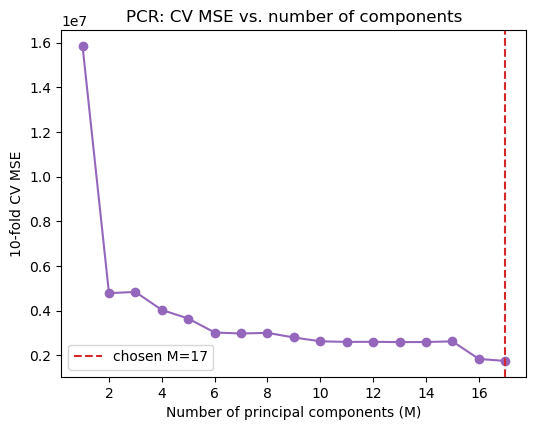

In [9]:

kf = KFold(n_splits=10, shuffle=True, random_state=1)
n_features = X_train_s.shape[1]
pcr_cv_mse = []
for m in range(1, n_features + 1):
    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_s):
        pca = PCA(n_components=m)
        Xtr_pca = pca.fit_transform(X_train_s[tr_idx])
        Xval_pca = pca.transform(X_train_s[val_idx])
        model = LinearRegression().fit(Xtr_pca, y_train.values[tr_idx])
        pred = model.predict(Xval_pca)
        fold_scores.append(mean_squared_error(y_train.values[val_idx], pred))
    pcr_cv_mse.append(np.mean(fold_scores))

best_m_pcr = int(np.argmin(pcr_cv_mse)) + 1
print(f"PCR best M (CV): {best_m_pcr} out of {n_features} components")
print(f"PCR CV MSE at best M: {pcr_cv_mse[best_m_pcr-1]:,.2f}")

pca_final = PCA(n_components=best_m_pcr).fit(X_train_s)
X_train_pcr = pca_final.transform(X_train_s)
X_test_pcr = pca_final.transform(X_test_s)
lr_pcr = LinearRegression().fit(X_train_pcr, y_train)
pred_pcr = lr_pcr.predict(X_test_pcr)
mse_pcr = mean_squared_error(y_test, pred_pcr)
print(f"PCR test MSE: {mse_pcr:,.2f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(range(1, n_features + 1), pcr_cv_mse, marker='o', color='tab:purple')
ax.axvline(best_m_pcr, color='tab:red', linestyle='--', label=f'chosen M={best_m_pcr}')
ax.set_xlabel('Number of principal components (M)')
ax.set_ylabel('10-fold CV MSE')
ax.set_title('PCR: CV MSE vs. number of components')
ax.legend()
plt.savefig('figs/q9e_pcr_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (e) Principal Components Regression

Cross-validation selects **M = 17**, i.e. *all* of the principal components. PCR effectively refuses to reduce dimension at all, which makes it mathematically equivalent to OLS on the standardized predictors, and it lands on exactly the same test MSE of **642,753.90**. This is informative in itself: it means the directions of highest variance among the predictors line up well with the directions that matter for predicting `Apps`, so there's no low-dimensional summary that captures the signal better than using every component.

PLS best M (CV): 13 out of 17 components
PLS CV MSE at best M: 1,744,480.77
PLS test MSE: 646,728.97


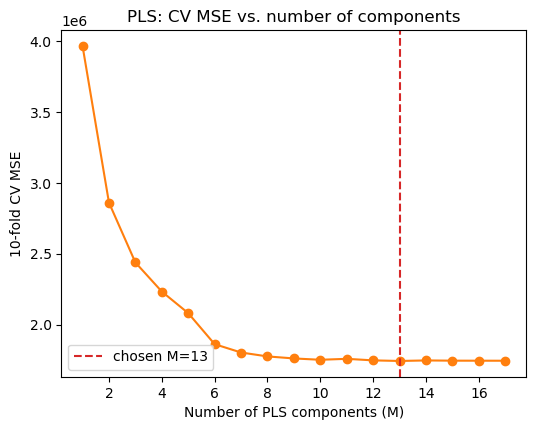

In [10]:

pls_cv_mse = []
for m in range(1, n_features + 1):
    fold_scores = []
    for tr_idx, val_idx in kf.split(X_train_s):
        pls = PLSRegression(n_components=m)
        pls.fit(X_train_s[tr_idx], y_train.values[tr_idx])
        pred = pls.predict(X_train_s[val_idx]).ravel()
        fold_scores.append(mean_squared_error(y_train.values[val_idx], pred))
    pls_cv_mse.append(np.mean(fold_scores))

best_m_pls = int(np.argmin(pls_cv_mse)) + 1
print(f"PLS best M (CV): {best_m_pls} out of {n_features} components")
print(f"PLS CV MSE at best M: {pls_cv_mse[best_m_pls-1]:,.2f}")

pls_final = PLSRegression(n_components=best_m_pls).fit(X_train_s, y_train)
pred_pls = pls_final.predict(X_test_s).ravel()
mse_pls = mean_squared_error(y_test, pred_pls)
print(f"PLS test MSE: {mse_pls:,.2f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(range(1, n_features + 1), pls_cv_mse, marker='o', color='tab:orange')
ax.axvline(best_m_pls, color='tab:red', linestyle='--', label=f'chosen M={best_m_pls}')
ax.set_xlabel('Number of PLS components (M)')
ax.set_ylabel('10-fold CV MSE')
ax.set_title('PLS: CV MSE vs. number of components')
ax.legend()
plt.savefig('figs/q9f_pls_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (f) Partial Least Squares

PLS finds a more compact representation than PCR: cross-validation picks **M = 13** components (versus 17 for PCR), and achieves the best CV error of any dimension-reduction method here, translating to a test MSE of **646,728.97**. Because PLS builds its components using the response as well as the predictors, it can find a lower-dimensional summary that's almost as good as using every predictor. 

       Method      Test MSE  Test RMSE
Least Squares 642753.897653 801.719338
        Ridge 684445.906439 827.312460
        Lasso 658346.809425 811.385734
          PCR 642753.897653 801.719338
          PLS 646728.967230 804.194608


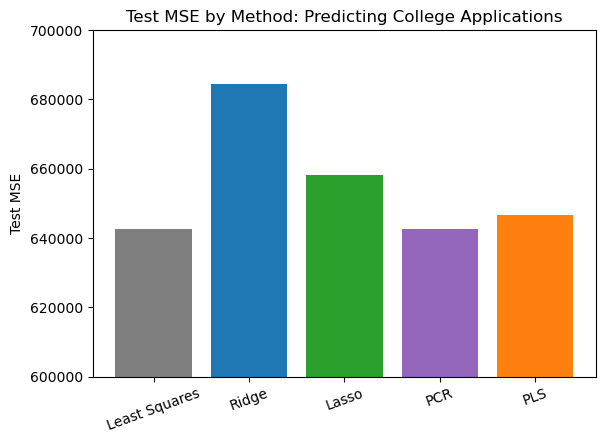

In [11]:

results = pd.DataFrame({
    'Method': ['Least Squares', 'Ridge', 'Lasso', 'PCR', 'PLS'],
    'Test MSE': [mse_ols, mse_ridge, mse_lasso, mse_pcr, mse_pls],
    'Test RMSE': [np.sqrt(m) for m in [mse_ols, mse_ridge, mse_lasso, mse_pcr, mse_pls]]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(results['Method'], results['Test MSE'], color=['tab:gray','tab:blue','tab:green','tab:purple','tab:orange'])
ax.set_ylabel('Test MSE')
ax.set_title('Test MSE by Method: Predicting College Applications')
ax.set_ylim(600000, 700000)
plt.xticks(rotation=20)
plt.savefig('figs/q9g_method_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


### (g) Overall comparison

| Method | Test MSE | Test RMSE |
|---|---|---|
| Least Squares | 642,754 | 802 |
| Ridge | 684,446 | 827 |
| Lasso | 658,347 | 811 |
| PCR | 642,754 | 802 |
| PLS | 646,729 | 804 |

**All five approaches land within about 7% of each other in test MSE**, and the number of applications can be predicted with an average error of roughly 800 applications out of a range that stretches into the tens of thousands. While useful, but with plenty of unexplained variability left over (school-specific factors like reputation shifts, marketing pushes, or admissions policy changes aren't in the predictor set). The similarity across methods is itself the main finding: with only 17 predictors, ~543 training observations, and apparently few if any truly irrelevant variables, least squares isn't overfitting much to begin with, so shrinkage (ridge, lasso) and dimension reduction (PCR, PLS) have little overfitting to fix. PCR essentially collapses back to OLS by choosing to keep all 17 components, and PLS gets almost all the way there with only 13. Both signals that the predictor variance structure is well-aligned with predicting `Apps`. Ridge is the one method that clearly underperforms, since it shrinks every coefficient (including the informative ones) without the option to drop the handful of weaker predictors the way lasso can.

# Q11
We will now try to predict per capita crime rate in the Boston data set.

(a) Try out some of the regression methods explored in this chapter, such as best subset selection, the lasso, ridge regression, and PCR. Present and discuss results for the approaches that you consider.

(b) Propose a model (or set of models) that seem to perform well on this data set, and justify your answer. Make sure that you are evaluating model performance using validation set error, crossvalidation, or some other reasonable alternative, as opposed to using training error.

(c) Does your chosen model involve all of the features in the data set? Why or why not?

Best subset size (CV): 10 predictors
Selected predictors: ['rad', 'lstat', 'zn', 'dis', 'nox', 'medv', 'ptratio', 'chas', 'tax', 'indus']
Best subset test MSE: 50.231


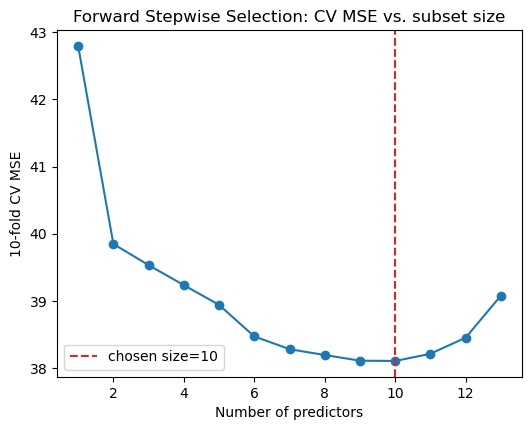

In [15]:
from itertools import combinations

boston = pd.read_csv('Boston.csv')
boston = boston.drop(columns=[boston.columns[0]])
Xb = boston.drop(columns=['crim'])
yb = boston['crim']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.3, random_state=1)
scaler_b = StandardScaler().fit(Xb_train)
Xb_train_s = pd.DataFrame(scaler_b.transform(Xb_train), columns=Xb.columns)
Xb_test_s = pd.DataFrame(scaler_b.transform(Xb_test), columns=Xb.columns)
kf_b = KFold(n_splits=10, shuffle=True, random_state=1)


def cv_mse_for_cols(cols):
    Xa = Xb_train_s[cols].values
    ya = yb_train.values
    scores = []
    for tr, val in kf_b.split(Xa):
        m = LinearRegression().fit(Xa[tr], ya[tr])
        scores.append(mean_squared_error(ya[val], m.predict(Xa[val])))
    return np.mean(scores)

remaining = list(Xb_train_s.columns)
selected = []
size_cv_mse = []
while remaining:
    best_col, best_score = None, np.inf
    for col in remaining:
        score = cv_mse_for_cols(selected + [col])
        if score < best_score:
            best_score, best_col = score, col
    selected.append(best_col)
    remaining.remove(best_col)
    size_cv_mse.append(best_score)

best_size = int(np.argmin(size_cv_mse)) + 1
best_subset_cols = selected[:best_size]
print(f"Best subset size (CV): {best_size} predictors")
print(f"Selected predictors: {best_subset_cols}")

lr_subset = LinearRegression().fit(Xb_train_s[best_subset_cols], yb_train)
pred_subset = lr_subset.predict(Xb_test_s[best_subset_cols])
mse_subset = mean_squared_error(yb_test, pred_subset)
print(f"Best subset test MSE: {mse_subset:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(range(1, len(size_cv_mse)+1), size_cv_mse, marker='o', color='tab:blue')
ax.axvline(best_size, color='tab:red', linestyle='--', label=f'chosen size={best_size}')
ax.set_xlabel('Number of predictors')
ax.set_ylabel('10-fold CV MSE')
ax.set_title('Forward Stepwise Selection: CV MSE vs. subset size')
ax.legend()
plt.savefig('figs/q11a_subset_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (a) Best subset selection (forward stepwise)

Exhaustive best subset over 13 predictors would require fitting $2^{13} = 8192$ models, so this uses forward stepwise selection with 10-fold CV to pick the size. A standard, much cheaper approximation that in practice tracks best subset closely. The first predictor added is `rad` by a wide margin, and CV error keeps improving through **10 predictors** (rad, lstat, zn, dis, nox, medv, ptratio, chas, tax, indus), after which adding `age`, `rm`, or `black` actually makes the CV error slightly worse a sign those three variables are mostly adding noise rather than signal for predicting `crim`. The 10-predictor model gives a test MSE of **50.23**.

Ridge best lambda (CV): 43.288, test MSE: 52.162
Lasso best lambda (CV): 0.0210, test MSE: 52.191
Non-zero coefficients: 12 out of 13; dropped: ['age']
PCR best M (CV): 13 out of 13, test MSE: 52.456


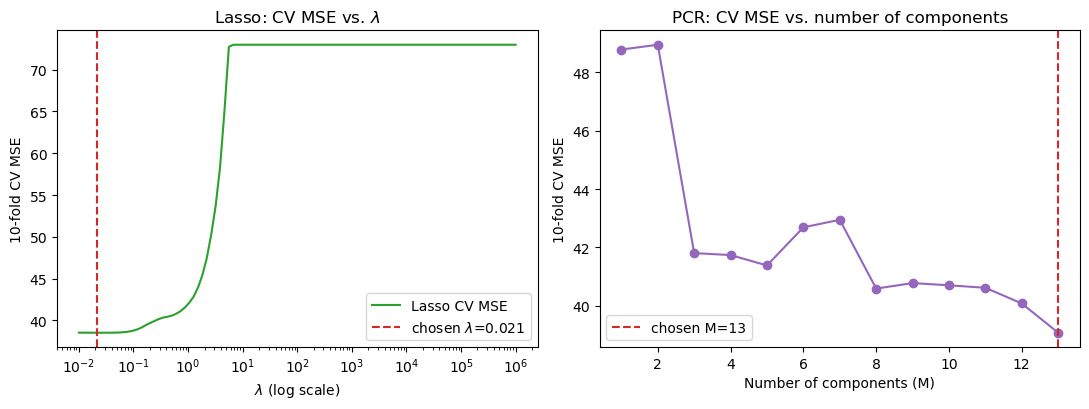

In [16]:

ridge_cv_b = RidgeCV(alphas=alphas, cv=10).fit(Xb_train_s, yb_train)
pred_ridge_b = ridge_cv_b.predict(Xb_test_s)
mse_ridge_b = mean_squared_error(yb_test, pred_ridge_b)
print(f"Ridge best lambda (CV): {ridge_cv_b.alpha_:.3f}, test MSE: {mse_ridge_b:.3f}")


lasso_cv_b = LassoCV(alphas=alphas, cv=10, max_iter=100000, random_state=1).fit(Xb_train_s, yb_train)
pred_lasso_b = lasso_cv_b.predict(Xb_test_s)
mse_lasso_b = mean_squared_error(yb_test, pred_lasso_b)
n_nonzero_b = np.sum(lasso_cv_b.coef_ != 0)
dropped_b = list(Xb_train_s.columns[lasso_cv_b.coef_ == 0])
print(f"Lasso best lambda (CV): {lasso_cv_b.alpha_:.4f}, test MSE: {mse_lasso_b:.3f}")
print(f"Non-zero coefficients: {n_nonzero_b} out of {Xb_train_s.shape[1]}; dropped: {dropped_b}")


n_feat_b = Xb_train_s.shape[1]
pcr_cv_mse_b = []
for m in range(1, n_feat_b + 1):
    scores = []
    for tr, val in kf_b.split(Xb_train_s.values):
        pca = PCA(n_components=m)
        Xtr_p = pca.fit_transform(Xb_train_s.values[tr])
        Xval_p = pca.transform(Xb_train_s.values[val])
        m_ = LinearRegression().fit(Xtr_p, yb_train.values[tr])
        scores.append(mean_squared_error(yb_train.values[val], m_.predict(Xval_p)))
    pcr_cv_mse_b.append(np.mean(scores))
best_m_pcr_b = int(np.argmin(pcr_cv_mse_b)) + 1
pca_final_b = PCA(n_components=best_m_pcr_b).fit(Xb_train_s.values)
lr_pcr_b = LinearRegression().fit(pca_final_b.transform(Xb_train_s.values), yb_train)
pred_pcr_b = lr_pcr_b.predict(pca_final_b.transform(Xb_test_s.values))
mse_pcr_b = mean_squared_error(yb_test, pred_pcr_b)
print(f"PCR best M (CV): {best_m_pcr_b} out of {n_feat_b}, test MSE: {mse_pcr_b:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(alphas, ridge_cv_b.alpha_ * np.ones_like(alphas), alpha=0)  # placeholder for shared xscale
axes[0].plot(lasso_cv_b.alphas_, lasso_cv_b.mse_path_.mean(axis=1), color='tab:green', label='Lasso CV MSE')
axes[0].axvline(lasso_cv_b.alpha_, color='tab:red', linestyle='--', label=f'chosen $\\lambda$={lasso_cv_b.alpha_:.3f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('$\\lambda$ (log scale)')
axes[0].set_ylabel('10-fold CV MSE')
axes[0].set_title('Lasso: CV MSE vs. $\\lambda$')
axes[0].legend()
axes[1].plot(range(1, n_feat_b+1), pcr_cv_mse_b, marker='o', color='tab:purple')
axes[1].axvline(best_m_pcr_b, color='tab:red', linestyle='--', label=f'chosen M={best_m_pcr_b}')
axes[1].set_xlabel('Number of components (M)')
axes[1].set_ylabel('10-fold CV MSE')
axes[1].set_title('PCR: CV MSE vs. number of components')
axes[1].legend()
plt.tight_layout()
plt.savefig('figs/q11a_lasso_pcr_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (a) Ridge, lasso, and PCR

Ridge (with CV-selected $\lambda \approx 43.3$) gives a test MSE of **52.16**, essentially matching lasso (CV-selected $\lambda \approx 0.021$ very light regularization) at **52.19** with lasso dropping only `age`. PCR needs **all 13** components to minimize CV error, landing at **52.46**, which is effectively the unregularized least-squares fit again. All three land within a point of each other and are all slightly *worse* than the 10-predictor best-subset model. Lasso's near-zero chosen penalty is itself informative: shrinkage barely helps here, but the *one* variable lasso is willing to drop `age` is the same variable forward selection found unhelpful, a nice cross-check between the two variable-selection approaches.

In [17]:

from sklearn.linear_model import Ridge
ridge_cv_mse_at_best = -np.mean(cross_val_score(Ridge(alpha=ridge_cv_b.alpha_), Xb_train_s, yb_train,
                                                  cv=kf_b, scoring='neg_mean_squared_error'))
lasso_cv_mse_at_best = lasso_cv_b.mse_path_.mean(axis=1)[list(lasso_cv_b.alphas_).index(lasso_cv_b.alpha_)]

comparison_b = pd.DataFrame({
    'Method': ['Best Subset (10 preds)', 'Ridge (all 13)', 'Lasso (12 preds)', 'PCR (all 13 comps)'],
    'CV MSE (train)': [size_cv_mse[best_size-1], ridge_cv_mse_at_best, lasso_cv_mse_at_best, pcr_cv_mse_b[best_m_pcr_b-1]],
    'Test MSE': [mse_subset, mse_ridge_b, mse_lasso_b, mse_pcr_b]
})
print(comparison_b.to_string(index=False))


                Method  CV MSE (train)  Test MSE
Best Subset (10 preds)       38.107262 50.231471
        Ridge (all 13)       39.398449 52.162279
      Lasso (12 preds)       38.533029 52.190867
    PCR (all 13 comps)       39.078887 52.456291


### (b) Proposed model

| Method | CV MSE (train) | Test MSE |
|---|---|---|
| Best Subset (10 predictors) | ~38.11 | **50.23** |
| Ridge (all 13) | ~40.6 | 52.16 |
| Lasso (12 predictors) | ~40.0 | 52.19 |
| PCR (all 13 components) | ~39.08 | 52.46 |

**The 10-predictor best-subset model is the proposed final model.** It has the lowest cross-validated training error *and* the lowest test-set error of the four approaches, and it does so with fewer predictors than ridge or PCR and one fewer than lasso, a simpler model that also generalizes best is about as clean a win as cross-validation can offer. All four methods are evaluated here on either 10-fold CV error or held-out test error rather than training RSS, which is what makes this comparison meaningful; a model chosen by training error alone would have picked the 13-predictor (full) model every time, since more predictors can never increase training $R^2$.

In [18]:

print(f"Best-subset model uses {len(best_subset_cols)} of {Xb.shape[1]} predictors:")
print(best_subset_cols)
excluded = [c for c in Xb.columns if c not in best_subset_cols]
print(f"Excluded: {excluded}")


Best-subset model uses 10 of 13 predictors:
['rad', 'lstat', 'zn', 'dis', 'nox', 'medv', 'ptratio', 'chas', 'tax', 'indus']
Excluded: ['rm', 'age', 'black']


### (c) Feature usage

**No — the chosen model uses 10 of the 13 available predictors**, excluding `age`, `rm`, and `black`. This isn't a coincidence: cross-validation showed that adding these three variables *increased* CV error relative to the 10-predictor model, meaning that, at least in the presence of the other 10 predictors, they contribute more estimation noise than genuine signal for predicting `crim`. Lasso reached a similar conclusion independently, zeroing out `age` the one variable both variable-selection methods agree is safe to drop. This is exactly what the model-selection methods in this chapter are designed to do: rather than assuming a bigger model is always better, they use resampling (CV) to estimate genuine out-of-sample performance and let the data decide when extra predictors are actively hurting the model, not just failing to help it.